In [1]:
# SOURCE:
# https://github.com/nflverse/nflverse-data/releases
# https://github.com/nflverse/nfldata

In [2]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from datetime import datetime
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier 
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

In [3]:
print(sys.path)

['C:\\Users\\Eventh\\Documents\\GitHub\\PortfolioProject\\notebooks', 'C:\\ProgramData\\anaconda3\\python311.zip', 'C:\\ProgramData\\anaconda3\\DLLs', 'C:\\ProgramData\\anaconda3\\Lib', 'C:\\ProgramData\\anaconda3', '', 'C:\\ProgramData\\anaconda3\\Lib\\site-packages', 'C:\\ProgramData\\anaconda3\\Lib\\site-packages\\win32', 'C:\\ProgramData\\anaconda3\\Lib\\site-packages\\win32\\lib', 'C:\\ProgramData\\anaconda3\\Lib\\site-packages\\Pythonwin']


In [4]:
os.getcwd()

'C:\\Users\\Eventh\\Documents\\GitHub\\PortfolioProject\\notebooks'

In [5]:
path = os.path.normpath(os.getcwd() + os.sep + os.pardir)

In [6]:
df = pd.read_csv(path + "/data/raw/games.csv", sep=",")
pd.set_option("display.max_columns", 200) # set max columns to 200, so df.head() shows all(max 200) columns    
# rename qb columns
df = df.rename(columns={"away_qb_name": "away_qb", "home_qb_name": "home_qb"})
df.head()

,game_id,season,game_type,week,gameday,weekday,gametime,away_team,away_score,home_team,home_score,location,result,total,overtime,old_game_id,gsis,nfl_detail_id,pfr,pff,espn,ftn,away_rest,home_rest,away_moneyline,home_moneyline,spread_line,away_spread_odds,home_spread_odds,total_line,under_odds,over_odds,div_game,roof,surface,temp,wind,away_qb_id,home_qb_id,away_qb,home_qb,away_coach,home_coach,referee,stadium_id,stadium
0,1999_01_MIN_ATL,1999,REG,1,1999-09-12,Sunday,NaN,MIN,17.0,ATL,14.0,Home,-3.0,31.0,0.0,1999091210,598.0,NaN,199909120atl,NaN,190912001,NaN,7,7,NaN,NaN,-4.0,NaN,NaN,49.0,NaN,NaN,0,dome,astroturf,NaN,NaN,00-0003761,00-0002876,Randall Cunningham,Chris Chandler,Dennis Green,Dan Reeves,Gerry Austin,ATL00,Georgia Dome
1,1999_01_KC_CHI,1999,REG,1,1999-09-12,Sunday,NaN,KC,17.0,CHI,20.0,Home,3.0,37.0,0.0,1999091206,597.0,NaN,199909120chi,NaN,190912003,NaN,7,7,NaN,NaN,-3.0,NaN,NaN,38.0,NaN,NaN,0,outdoors,grass,80.0,12.0,00-0006300,00-0010560,Elvis Grbac,Shane Matthews,Gunther Cunningham,Dick Jauron,Phil Luckett,CHI98,Soldier Field
2,1999_01_PIT_CLE,1999,REG,1,1999-09-12,Sunday,NaN,PIT,43.0,CLE,0.0,Home,-43.0,43.0,0.0,1999091213,604.0,NaN,199909120cle,NaN,190912005,NaN,7,7,NaN,NaN,-6.0,NaN,NaN,37.0,NaN,NaN,1,outdoors,grass,78.0,12.0,00-0015700,00-0004230,Kordell Stewart,Ty Detmer,Bill Cowher,Chris Palmer,Bob McElwee,CLE00,Cleveland Browns Stadium
3,1999_01_OAK_GB,1999,REG,1,1999-09-12,Sunday,NaN,OAK,24.0,GB,28.0,Home,4.0,52.0,0.0,1999091208,602.0,NaN,199909120gnb,NaN,190912009,NaN,7,7,NaN,NaN,9.0,NaN,NaN,43.0,NaN,NaN,0,outdoors,grass,67.0,10.0,00-0005741,00-0005106,Rich Gannon,Brett Favre,Jon Gruden,Ray Rhodes,Tony Corrente,GNB00,Lambeau Field
4,1999_01_BUF_IND,1999,REG,1,1999-09-12,Sunday,NaN,BUF,14.0,IND,31.0,Home,17.0,45.0,0.0,1999091202,591.0,NaN,199909120clt,NaN,190912011,NaN,7,7,NaN,NaN,-3.0,NaN,NaN,45.5,NaN,NaN,1,dome,astroturf,NaN,NaN,00-0005363,00-0010346,Doug Flutie,Peyton Manning,Wade Phillips,Jim Mora,Ron Blum,IND99,RCA Dome


In [99]:
# Cleaning function
def clean_df(df, start_season=2000):
    # ---------- DROP COLUMNS AND ROWS ---------- 
    # we will drop additional columns later with an extra function, because we need them to create additional features
    # drop bet related columns
    # we also drop the scores, totals and results after creating our target "win".
    df = df.drop(columns=['away_moneyline', 'home_moneyline', 'spread_line', 'away_spread_odds',
                          'home_spread_odds', 'total_line', 'under_odds', 'over_odds'])
    # drop double columns
    df = df.drop(columns=['away_qb_id', 'home_qb_id', 'stadium_id'])
    
    # select starting season via start_season
    # all missing gametimes are in the '99 season, so we set start_seasons default to 2000, to drop atleast the 1999 season
    df = df.loc[df['season'] >= start_season, :]
    df = df.reset_index(drop=True)
    
    # ---------- CREATE NEW COLUMNS ---------- 
    # check the current date
    now = datetime.now()
    # fill NaNs in gametime, so we can convert to datetime
    df["gametime"] = df["gametime"].fillna("11:11")
    # convert gameday and gametime to datetime 
    df['gameday'] = pd.to_datetime(df['gameday'])
    df['gametime'] = pd.to_datetime(df['gametime'], format="%H:%M")
    # extract hour and minute from the gametime
    df["gametime_h"] = df.loc[:, "gametime"].dt.hour
    # convert gametime to string only showing "HH:MM"
    df['gametime'] = df['gametime'].dt.strftime("%H:%M")
    # combine both columns to get gameday + gametime as one, so we can compare it to now
    df['datetime'] = pd.to_datetime(df['gameday'].astype(str) + ' ' + df['gametime'])
    # replace our imputation value with NaNs again
    df["gametime"] = df["gametime"].replace("11:11:00", np.nan)
    # filter rows where "datetime" is greater than "now" to drop future games
    df = df[df['datetime'] < now]
    # create month column
    df["month"] = df["gameday"].dt.month
    # create target column "win"
    # np.where(condition = df["result"] > 0, then = 1, else = 0)
    df["win"] = np.where(df["result"] > 0, 1, 0)

    # ---------- IMPUTATION OF TEAMS ---------- 
    # merge old with new team names
    # OLD - NEW Team name
    # OAK (Oakland Raiders) - LV (Las Vegas Raiders) 
    # SD (San Diego Chargers) - LAC (Los Angeles Chargers)
    # STL (St. Louis Rams) - LA (Los Angeles Rams)
    team_cols = ["away_team", "home_team"]
    for col in team_cols:
        df.loc[:, col] = df.loc[:, col].replace({"OAK": "LV", 
                                                "SD": "LAC", 
                                                "STL": "LA"})
      
    # ---------- IMPUTATION OF SURFACE ---------- 
    # everything else than grass is synthetic or hybrid grass
    # combine all synthetic and hybrid under 'synthetic'
    # combine both grass
    df.loc[:, "surface"] = df.loc[:, "surface"].replace(["fieldturf", "astroturf", "sportturf", "matrixturf", "astroplay", "a_turf", "dessograss"], "synthetic")
    df.loc[:, "surface"] = df.loc[:, "surface"].replace("grass ", "grass")

    # get array of all stadiums that contain NaNs in surface column
    surface_nan = df.loc[df["surface"].isna(), "stadium"].unique()
    # first fill NaNs with "Unkown", so we dont get errors while using .mode() with NaNs
    df["surface"] = df["surface"].fillna("Unkown")
    for stadium in surface_nan:
        surface_mode = df.loc[df["stadium"] == stadium, "surface"].mode()[0]
        # if the mode of the surface is "Unkown", we dont have enough data for the given stadium, therefore we impute with the overall mode surface of all stadiums
        if surface_mode == "Unkown":
            df.loc[df["stadium"] == stadium, "surface"] = df["surface"].mode()[0]
        # if we have enough data for the given stadium, we impute with the mode surface of the given stadium
        else:
            df.loc[df["stadium"] == stadium, "surface"] = df["surface"].replace("Unkown", surface_mode)
    # replace "Unkown" surface with NaNs again, so its easier to spot missed imputations
    df["surface"] = df["surface"].replace("Unkown", np.nan)

    # ---------- IMPUTATION OF TEMPERATURE & WIND ---------- 
    # wind [mph] - 71 mph x 1.609 = 114.263 kmh
    # temp [°F] - (109 °F − 32) × 5/9 = 42.778 °C
    # web crawling for weather: https://www.wunderground.com/history
    # create crosstabs of the median value of temperate & wind for each month in each stadium for future imputation
    ct_temp = pd.crosstab(df["month"], df["stadium"], values=df["temp"], aggfunc="median", dropna=False)
    ct_wind = pd.crosstab(df["month"], df["stadium"], values=df["wind"], aggfunc="median", dropna=False) 
    # get array of all stadiums that contain NaNs in temp & wind column
    temp_nan = df.loc[df["temp"].isna(), "stadium"].unique()
    wind_nan = df.loc[df["wind"].isna(), "stadium"].unique()           
    
    # iterate through the left NaNs in temp
    for stadium in temp_nan:
        # try to imputate by the monthly median temp for each stadium
        for month in df["month"].unique():
            if df.loc[(df["stadium"] == stadium) & (df["month"] == month), "temp"].isna().any():
                df.loc[(df["stadium"] == stadium) & (df["month"] == month), "temp"] = df.loc[(df["stadium"] == stadium) & (df["month"] == month), "temp"].fillna(ct_temp.loc[month, stadium])  
        # if there are still NaNs left, imputate by the overall median temp for each stadium
        df.loc[df["stadium"] == stadium, "temp"] = df.loc[df["stadium"] == stadium, "temp"].fillna(df.loc[df["stadium"] == stadium, "temp"].median())
    
    # iterate through the left NaNs in wind  
    for stadium in wind_nan:
        # try to imputate by the monthly median wind for each stadium
        for month in df["month"].unique():
            if df.loc[(df["stadium"] == stadium) & (df["month"] == month), "temp"].isna().any():
                df.loc[(df["stadium"] == stadium) & (df["month"] == month), "wind"] = df.loc[(df["stadium"] == stadium) & (df["month"] == month), "wind"].fillna(ct_wind.loc[month, stadium])   
        # if there are still NaNs left, imputate by the overall median wind for each stadium
        df.loc[df["stadium"] == stadium, "wind"] = df.loc[df["stadium"] == stadium, "wind"].fillna(df.loc[df["stadium"] == stadium, "wind"].median())
    
    # left out cities gathered by hand
    # looking for data at: https://www.wunderground.com/history/monthly/us/tx/dallas/date/2020-11
    # we will use the average temperate of 2020-11 at the given state
    # FUTURE: web crawling
    city_temp_wind = {"DAL": [61.2, 7.8],
                      "NO": [61.2, 7.6],
                      "LV": [61.2, 6.3],
                      "TB": [61.2, 7.7],
                      "LA": [61.2, 3.5],
                      "LAC": [61.2, 3.5],
                      "DET": [61.2, 9.8],
                      "ATL": [61.2, 8.4],
                      "MIN": [61.2, 8.9],
                      "IND": [61.2, 10.84],
                      "HOU": [61.2, 7.8],
                      "BUF": [61.2, 12.3],
                      "ARI": [61.2, 4.7]}
    
    for city, value in city_temp_wind.items():
        # select the most played stadium of the home team, we also imputate the location = "Neutral" games
        # this can lead to errors as we don't take into account the potential relocation of a team
        df.loc[df["home_team"] == city, "temp"] = df.loc[df["home_team"] == city, "temp"].fillna(value[0])
        df.loc[df["home_team"] == city, "wind"] = df.loc[df["home_team"] == city, "wind"].fillna(value[1])
        
    # get array of all stadiums that contain NaNs in temp & wind column
    temp_nan = df.loc[df["temp"].isna(), "stadium"].unique()
    wind_nan = df.loc[df["wind"].isna(), "stadium"].unique()     
    
    for stadium in temp_nan:
        df.loc[df["stadium"] == stadium, "temp"] = df.loc[df["stadium"] == stadium, "temp"].fillna(df.loc[df["stadium"] == stadium, "temp"].median())
    for stadium in wind_nan:
        df.loc[df["stadium"] == stadium, "wind"] = df.loc[df["stadium"] == stadium, "wind"].fillna(df.loc[df["stadium"] == stadium, "wind"].median())
    
    # ---------- IMPUTATION OF QB's ---------- 
    # done by hand for now
    # https://www.nfl.com/games/patriots-at-colts-2021-reg-15
    # FUTURE: web crawling
    missing_qbs = [["Russel Wilson", "Patrick Mahomes"],
                   ["Lamar Jackson", "Ryan Tannehill"],
                   ["Sam Howell", "Desmond Ridder"],
                   ["Kirk Cousins"," Tyson Bagent"],
                   ["Geno Smith", "Joe Burrow"],
                   ["Derek Carr", "C.J. Stroud"],
                   ["Gardner Minshew", "Trevor Lawrence"],
                   ["Bryce Young", "Tua Tagovailoa"]]

    k = 0
    for i in range(6240, 6249):
        if i == 6245:
            k += 1
        df.loc[i, "away_qb"] = missing_qbs[i-6240-k][0]
        df.loc[i, "home_qb"] = missing_qbs[i-6240-k][1]
        
    # ---------- IMPUTATION OF REFEREES ---------- 
    # done by hand for now
    # FUTURE: web crawling
    # Carl Cheffers - https://www.espn.com/nfl/game?gameId=401326540&_slug_=patriots-colts
    df.loc[5802, "referee"] = "Carl Cheffers"
    df.loc[6442, "referee"] = "Bill Vinovich"
    df.loc[6443, "referee"] = "Shawn Hochuli"

    # ----- IMPORTANT ------
    # maybe keep espn-id to crawl data from - https://www.espn.com/nfl/game?gameId=401326540
    # same for pfr - https://www.pro-football-reference.com/boxscores/199909120atl.htm
    #
    # https://www.ftnfantasy.com/nfl/game-logs?page=ForLogsView&teamAbbv=ATL&year=2023 - for web crawling
    # https://www.footballdb.com/games/boxscore/miami-dolphins-vs-kansas-city-chiefs-2024011302
    # https://www.footballdb.com/teams/nfl/arizona-cardinals/seasons

    return df

In [71]:
df_clean = clean_df(df)

In [72]:
df_clean.head()

,season,game_type,week,gameday,weekday,gametime,away_team,away_score,home_team,home_score,location,result,total,away_rest,home_rest,div_game,roof,surface,temp,wind,away_qb,home_qb,away_coach,home_coach,referee,stadium,away_rating,home_rating,gametime_h,datetime,month,win
0,2000,REG,1,2000-09-03,Sunday,13:00,SF,28.0,ATL,36.0,Home,8.0,64.0,7,7,1,dome,synthetic,61.2,8.4,Jeff Garcia,Chris Chandler,Steve Mariucci,Dan Reeves,Walt Coleman,Georgia Dome,1500,1500,13,2000-09-03 13:00:00,9,1
1,2000,REG,1,2000-09-03,Sunday,13:00,JAX,27.0,CLE,7.0,Home,-20.0,34.0,7,7,1,outdoors,grass,78.0,6.0,Mark Brunell,Tim Couch,Tom Coughlin,Chris Palmer,Bernie Kukar,Cleveland Browns Stadium,1500,1500,13,2000-09-03 13:00:00,9,0
2,2000,REG,1,2000-09-03,Sunday,13:00,IND,27.0,KC,14.0,Home,-13.0,41.0,7,7,0,outdoors,grass,90.0,5.0,Peyton Manning,Elvis Grbac,Jim Mora,Gunther Cunningham,Larry Nemmers,Arrowhead Stadium,1500,1500,13,2000-09-03 13:00:00,9,0
3,2000,REG,1,2000-09-03,Sunday,13:00,CHI,27.0,MIN,30.0,Home,3.0,57.0,7,7,1,dome,synthetic,61.2,8.9,Cade McNown,Daunte Culpepper,Dick Jauron,Dennis Green,Ed Hochuli,Hubert H. Humphrey Metrodome,1500,1500,13,2000-09-03 13:00:00,9,1
4,2000,REG,1,2000-09-03,Sunday,13:00,TB,21.0,NE,16.0,Home,-5.0,37.0,7,7,0,outdoors,grass,71.0,5.0,Shaun King,Drew Bledsoe,Tony Dungy,Bill Belichick,Jeff Triplette,Foxboro Stadium,1500,1500,13,2000-09-03 13:00:00,9,0


In [9]:
df_clean.isna().sum()

season        0
game_type     0
week          0
gameday       0
weekday       0
gametime      0
away_team     0
home_team     0
location      0
away_rest     0
home_rest     0
div_game      0
roof          0
surface       0
temp          0
wind          0
away_qb       0
home_qb       0
away_coach    0
home_coach    0
referee       0
stadium       0
gametime_h    0
datetime      0
month         0
win           0
dtype: int64

In [10]:
df_clean.loc[df_clean["temp"].isna(), :]

,season,game_type,week,gameday,weekday,gametime,away_team,home_team,location,away_rest,home_rest,div_game,roof,surface,temp,wind,away_qb,home_qb,away_coach,home_coach,referee,stadium,gametime_h,datetime,month,win


In [11]:
df_clean.loc[517, :]

season                       2001
game_type                      SB
week                           21
gameday       2002-02-03 00:00:00
weekday                    Sunday
gametime                    18:40
away_team                      LA
home_team                      NE
location                  Neutral
away_rest                       7
home_rest                       7
div_game                        0
roof                         dome
surface                 synthetic
temp                         61.2
wind                          7.6
away_qb               Kurt Warner
home_qb                 Tom Brady
away_coach             Mike Martz
home_coach         Bill Belichick
referee              Bernie Kukar
stadium       Louisiana Superdome
gametime_h                     18
datetime      2002-02-03 18:40:00
month                           2
win                             1
Name: 517, dtype: object

In [12]:
df_clean.loc[517, "stadium"]

'Louisiana Superdome'

In [13]:
df_clean.loc[517, :].isna().sum()

0

In [14]:
df_clean.loc[df_clean["stadium"] == 'Louisiana Superdome', :].isna().sum()

season        0
game_type     0
week          0
gameday       0
weekday       0
gametime      0
away_team     0
home_team     0
location      0
away_rest     0
home_rest     0
div_game      0
roof          0
surface       0
temp          0
wind          0
away_qb       0
home_qb       0
away_coach    0
home_coach    0
referee       0
stadium       0
gametime_h    0
datetime      0
month         0
win           0
dtype: int64

In [15]:
df_clean.describe()

,season,week,gameday,away_rest,home_rest,div_game,temp,wind,gametime_h,datetime,month,win
count,6444.000000,6444.000000,6444,6444.000000,6444.000000,6444.000000,6444.000000,6444.000000,6444.000000,6444,6444.000000,6444.000000
mean,2011.610956,9.565798,2012-06-19 09:35:51.955307264,7.481378,7.514742,0.373526,58.861375,8.298035,14.925978,2012-06-20 00:39:47.169459968,9.880043,0.563625
min,2000.000000,1.000000,2000-09-03 00:00:00,4.000000,4.000000,0.000000,-6.000000,0.000000,9.000000,2000-09-03 13:00:00,1.000000,0.000000
25%,2006.000000,5.000000,2006-09-17 00:00:00,7.000000,7.000000,0.000000,51.000000,5.000000,13.000000,2006-09-17 15:18:45,9.000000,0.000000
50%,2012.000000,10.000000,2012-09-23 00:00:00,7.000000,7.000000,0.000000,61.200000,8.000000,13.000000,2012-09-23 13:00:00,10.000000,1.000000
75%,2018.000000,14.000000,2018-09-23 00:00:00,7.000000,7.000000,1.000000,66.000000,10.000000,16.000000,2018-09-23 13:46:15,12.000000,1.000000
max,2023.000000,22.000000,2024-01-21 00:00:00,21.000000,16.000000,1.000000,109.000000,71.000000,23.000000,2024-01-21 18:30:00,12.000000,1.000000
std,6.943796,5.316976,NaN,1.994201,2.095634,0.483777,14.712699,4.741760,2.699546,NaN,2.735147,0.495974


In [16]:
#sns.pairplot(df)

In [17]:
# ----- IMPORTANT ------
# maybe keep espn-id to crawl data from - https://www.espn.com/nfl/game?gameId=401326540
# same for pfr - https://www.pro-football-reference.com/boxscores/199909120atl.htm
#
# https://www.ftnfantasy.com/nfl/game-logs?page=ForLogsView&teamAbbv=ATL&year=2023 - for web crawling
# https://www.footballdb.com/games/boxscore/miami-dolphins-vs-kansas-city-chiefs-2024011302
# https://www.footballdb.com/teams/nfl/arizona-cardinals/seasons

In [18]:
# split columns into categorical and numerical cols for future use (Cat for Onehotencoding - Num for Scaling)
num_cols = df_clean.select_dtypes(include=[np.number]).columns
cat_cols = df_clean.select_dtypes(exclude=[np.number]).columns

<Axes: >

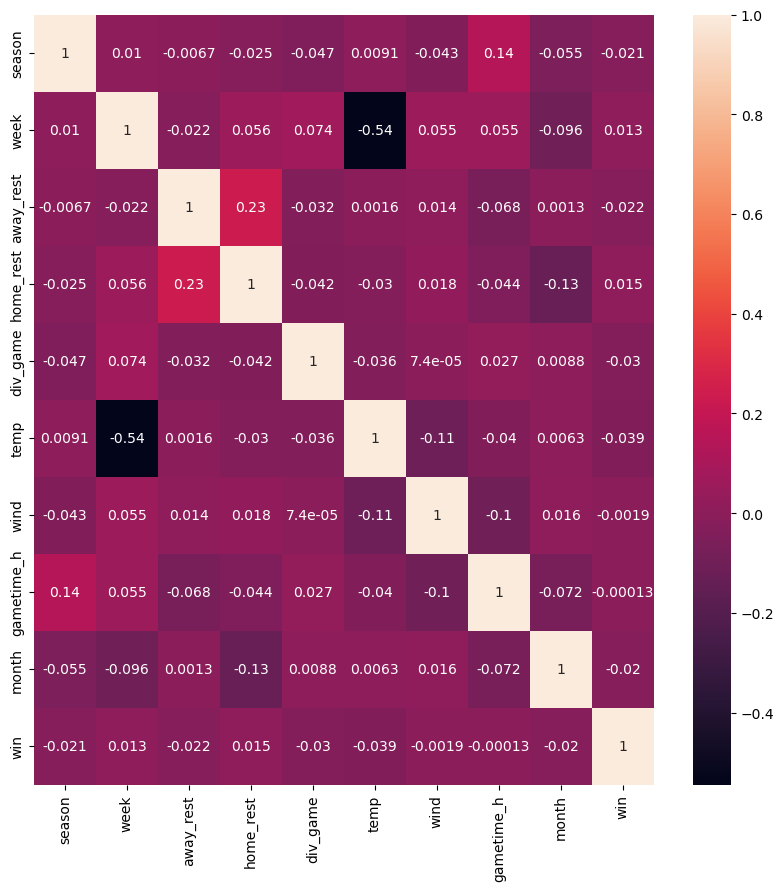

In [19]:
fig, ax = plt.subplots(figsize=(10,10))
corr = df_clean[num_cols].corr()
sns.heatmap(corr, annot=True, ax=ax)

In [20]:
# for the future:
# function to display win percentage by chosen type and value
# e.g. Type = team (columns = away_team & home_team), value = "IND" shows win percantage of the Indianapolis Colts

In [21]:
df_clean.groupby("win")["season"].count()

win
0    2812
1    3632
Name: season, dtype: int64

In [22]:
# split into train & test set
df_train = df_clean.loc[df_clean["season"] < 2020, :]
df_test = df_clean.loc[df_clean["season"] >= 2020, :]

In [23]:
df_train.head()

,season,game_type,week,gameday,weekday,gametime,away_team,home_team,location,away_rest,home_rest,div_game,roof,surface,temp,wind,away_qb,home_qb,away_coach,home_coach,referee,stadium,gametime_h,datetime,month,win
0,2000,REG,1,2000-09-03,Sunday,13:00,SF,ATL,Home,7,7,1,dome,synthetic,61.2,8.4,Jeff Garcia,Chris Chandler,Steve Mariucci,Dan Reeves,Walt Coleman,Georgia Dome,13,2000-09-03 13:00:00,9,1
1,2000,REG,1,2000-09-03,Sunday,13:00,JAX,CLE,Home,7,7,1,outdoors,grass,78.0,6.0,Mark Brunell,Tim Couch,Tom Coughlin,Chris Palmer,Bernie Kukar,Cleveland Browns Stadium,13,2000-09-03 13:00:00,9,0
2,2000,REG,1,2000-09-03,Sunday,13:00,IND,KC,Home,7,7,0,outdoors,grass,90.0,5.0,Peyton Manning,Elvis Grbac,Jim Mora,Gunther Cunningham,Larry Nemmers,Arrowhead Stadium,13,2000-09-03 13:00:00,9,0
3,2000,REG,1,2000-09-03,Sunday,13:00,CHI,MIN,Home,7,7,1,dome,synthetic,61.2,8.9,Cade McNown,Daunte Culpepper,Dick Jauron,Dennis Green,Ed Hochuli,Hubert H. Humphrey Metrodome,13,2000-09-03 13:00:00,9,1
4,2000,REG,1,2000-09-03,Sunday,13:00,TB,NE,Home,7,7,0,outdoors,grass,71.0,5.0,Shaun King,Drew Bledsoe,Tony Dungy,Bill Belichick,Jeff Triplette,Foxboro Stadium,13,2000-09-03 13:00:00,9,0


In [24]:
# dictionary with coaches [Total Games - W/L Ratio - Games with Team]
# dictionary with qbs [Total Games - W/L Ratio - Games with Team]

In [25]:
for col in df_train.columns:
    print(col, df_train[col].nunique())

season 20
game_type 5
week 21
gameday 1002
weekday 7
gametime 48
away_team 32
home_team 32
location 2
away_rest 12
home_rest 11
div_game 2
roof 4
surface 2
temp 103
wind 46
away_qb 253
home_qb 243
away_coach 136
home_coach 136
referee 82
stadium 87
gametime_h 13
datetime 2174
month 6
win 2


In [26]:
# feature engineering
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

In [27]:
df_clean.columns
# columns to use for baseline model: 
# ['season', 'game_type', 'week', 'weekday','away_team', 'away_score', 'home_team', 'home_score', 'location', 'overtime', 
#  'away_rest', 'home_rest', 'div_game','roof', 'surface', 'temp', 'wind', 'gametime_h', 'gametime_min']

Index(['season', 'game_type', 'week', 'gameday', 'weekday', 'gametime',
       'away_team', 'home_team', 'location', 'away_rest', 'home_rest',
       'div_game', 'roof', 'surface', 'temp', 'wind', 'away_qb', 'home_qb',
       'away_coach', 'home_coach', 'referee', 'stadium', 'gametime_h',
       'datetime', 'month', 'win'],
      dtype='object')

In [28]:
df_base = df_clean[['season', 'game_type', 'week', 'away_team', 'home_team', 'location', 
              'away_rest', 'home_rest', 'div_game','roof', 'surface', 'temp', 'wind', 
              'win']]
df_base.head()

,season,game_type,week,away_team,home_team,location,away_rest,home_rest,div_game,roof,surface,temp,wind,win
0,2000,REG,1,SF,ATL,Home,7,7,1,dome,synthetic,61.2,8.4,1
1,2000,REG,1,JAX,CLE,Home,7,7,1,outdoors,grass,78.0,6.0,0
2,2000,REG,1,IND,KC,Home,7,7,0,outdoors,grass,90.0,5.0,0
3,2000,REG,1,CHI,MIN,Home,7,7,1,dome,synthetic,61.2,8.9,1
4,2000,REG,1,TB,NE,Home,7,7,0,outdoors,grass,71.0,5.0,0


In [29]:
df_base.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6444 entries, 0 to 6443
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   season     6444 non-null   int64  
 1   game_type  6444 non-null   object 
 2   week       6444 non-null   int64  
 3   away_team  6444 non-null   object 
 4   home_team  6444 non-null   object 
 5   location   6444 non-null   object 
 6   away_rest  6444 non-null   int64  
 7   home_rest  6444 non-null   int64  
 8   div_game   6444 non-null   int64  
 9   roof       6444 non-null   object 
 10  surface    6444 non-null   object 
 11  temp       6444 non-null   float64
 12  wind       6444 non-null   float64
 13  win        6444 non-null   int32  
dtypes: float64(2), int32(1), int64(5), object(6)
memory usage: 988.0+ KB


In [30]:
# split df_base into train & test set
df_base_train = df_base.loc[df["season"] < 2020]
df_base_test = df_base.loc[df["season"] >= 2020]

# split further into features & target
features_base_train = df_base_train.drop(columns="win")
target_base_train = df_base_train["win"]
features_base_test = df_base_test.drop(columns="win")
target_base_test = df_base_test["win"]

In [31]:
df_base_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5583 entries, 0 to 5582
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   season     5583 non-null   int64  
 1   game_type  5583 non-null   object 
 2   week       5583 non-null   int64  
 3   away_team  5583 non-null   object 
 4   home_team  5583 non-null   object 
 5   location   5583 non-null   object 
 6   away_rest  5583 non-null   int64  
 7   home_rest  5583 non-null   int64  
 8   div_game   5583 non-null   int64  
 9   roof       5583 non-null   object 
 10  surface    5583 non-null   object 
 11  temp       5583 non-null   float64
 12  wind       5583 non-null   float64
 13  win        5583 non-null   int32  
dtypes: float64(2), int32(1), int64(5), object(6)
memory usage: 632.4+ KB


In [32]:
df_base_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 861 entries, 5583 to 6443
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   season     861 non-null    int64  
 1   game_type  861 non-null    object 
 2   week       861 non-null    int64  
 3   away_team  861 non-null    object 
 4   home_team  861 non-null    object 
 5   location   861 non-null    object 
 6   away_rest  861 non-null    int64  
 7   home_rest  861 non-null    int64  
 8   div_game   861 non-null    int64  
 9   roof       861 non-null    object 
 10  surface    861 non-null    object 
 11  temp       861 non-null    float64
 12  wind       861 non-null    float64
 13  win        861 non-null    int32  
dtypes: float64(2), int32(1), int64(5), object(6)
memory usage: 97.5+ KB


In [33]:
# split columns into categorical and numerical cols for future use (Cat for Onehotencoding - Num for Scaling)
num_cols = features_base_train.select_dtypes(include=[np.number]).columns
cat_cols = features_base_train.select_dtypes(exclude=[np.number]).columns

In [34]:
ohe = OneHotEncoder()
features_base_train_ohe = pd.DataFrame(ohe.fit_transform(features_base_train[cat_cols]).toarray(), columns=list(ohe.get_feature_names_out()))

In [35]:
features_base_train_ohe

,game_type_CON,game_type_DIV,game_type_REG,game_type_SB,game_type_WC,away_team_ARI,away_team_ATL,away_team_BAL,away_team_BUF,away_team_CAR,away_team_CHI,away_team_CIN,away_team_CLE,away_team_DAL,away_team_DEN,away_team_DET,away_team_GB,away_team_HOU,away_team_IND,away_team_JAX,away_team_KC,away_team_LA,away_team_LAC,away_team_LV,away_team_MIA,away_team_MIN,away_team_NE,away_team_NO,away_team_NYG,away_team_NYJ,away_team_PHI,away_team_PIT,away_team_SEA,away_team_SF,away_team_TB,away_team_TEN,away_team_WAS,home_team_ARI,home_team_ATL,home_team_BAL,home_team_BUF,home_team_CAR,home_team_CHI,home_team_CIN,home_team_CLE,home_team_DAL,home_team_DEN,home_team_DET,home_team_GB,home_team_HOU,home_team_IND,home_team_JAX,home_team_KC,home_team_LA,home_team_LAC,home_team_LV,home_team_MIA,home_team_MIN,home_team_NE,home_team_NO,home_team_NYG,home_team_NYJ,home_team_PHI,home_team_PIT,home_team_SEA,home_team_SF,home_team_TB,home_team_TEN,home_team_WAS,location_Home,location_Neutral,roof_closed,roof_dome,roof_open,roof_outdoors,surface_grass,surface_synthetic
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5578,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
5579,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
5580,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
5581,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,

In [36]:
scaler = StandardScaler()
features_base_train_scaled = pd.DataFrame(scaler.fit_transform(features_base_train[num_cols]), columns=num_cols)
features_base_train_scaled.head()

,season,week,away_rest,home_rest,div_game,temp,wind
0,-1.659132,-1.614313,-0.24818,-0.246444,1.282954,0.153426,0.015737
1,-1.659132,-1.614313,-0.24818,-0.246444,1.282954,1.291533,-0.484411
2,-1.659132,-1.614313,-0.24818,-0.246444,-0.779451,2.104468,-0.692806
3,-1.659132,-1.614313,-0.24818,-0.246444,1.282954,0.153426,0.119934
4,-1.659132,-1.614313,-0.24818,-0.246444,-0.779451,0.817322,-0.692806


In [37]:
features_base_train_enc = pd.concat([features_base_train_scaled, features_base_train_ohe], axis=1, join="inner")

In [38]:
features_base_train_enc.head()

,season,week,away_rest,home_rest,div_game,temp,wind,game_type_CON,game_type_DIV,game_type_REG,game_type_SB,game_type_WC,away_team_ARI,away_team_ATL,away_team_BAL,away_team_BUF,away_team_CAR,away_team_CHI,away_team_CIN,away_team_CLE,away_team_DAL,away_team_DEN,away_team_DET,away_team_GB,away_team_HOU,away_team_IND,away_team_JAX,away_team_KC,away_team_LA,away_team_LAC,away_team_LV,away_team_MIA,away_team_MIN,away_team_NE,away_team_NO,away_team_NYG,away_team_NYJ,away_team_PHI,away_team_PIT,away_team_SEA,away_team_SF,away_team_TB,away_team_TEN,away_team_WAS,home_team_ARI,home_team_ATL,home_team_BAL,home_team_BUF,home_team_CAR,home_team_CHI,home_team_CIN,home_team_CLE,home_team_DAL,home_team_DEN,home_team_DET,home_team_GB,home_team_HOU,home_team_IND,home_team_JAX,home_team_KC,home_team_LA,home_team_LAC,home_team_LV,home_team_MIA,home_team_MIN,home_team_NE,home_team_NO,home_team_NYG,home_team_NYJ,home_team_PHI,home_team_PIT,home_team_SEA,home_team_SF,home_team_TB,home_team_TEN,home_team_WAS,location_Home,location_Neutral,roof_closed,roof_dome,roof_open,roof_outdoors,surface_grass,surface_synthetic
0,-1.659132,-1.614313,-0.24818,-0.246444,1.282954,0.153426,0.015737,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,-1.659132,-1.614313,-0.24818,-0.246444,1.282954,1.291533,-0.484411,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
2,-1.659132,-1.614313,-0.24818,-0.246444,-0.779451,2.104468,-0.692806,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
3,-1.659132,-1.614313,-0.24818,-0.246444,1.282954,0.153426,0.119934,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,-1.659132,-1.614313,-0.24818,-0.246444,-0.779451,0.817322,-0.692806,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0


In [39]:
features_base_test_ohe = pd.DataFrame(ohe.transform(features_base_test[cat_cols]).toarray(), columns=list(ohe.get_feature_names_out()))
features_base_test_scaled = pd.DataFrame(scaler.transform(features_base_test[num_cols]), columns=num_cols)
features_base_test_enc = pd.concat([features_base_test_scaled, features_base_test_ohe], axis=1, join="inner")

In [40]:
features_base_test_enc.head()

,season,week,away_rest,home_rest,div_game,temp,wind,game_type_CON,game_type_DIV,game_type_REG,game_type_SB,game_type_WC,away_team_ARI,away_team_ATL,away_team_BAL,away_team_BUF,away_team_CAR,away_team_CHI,away_team_CIN,away_team_CLE,away_team_DAL,away_team_DEN,away_team_DET,away_team_GB,away_team_HOU,away_team_IND,away_team_JAX,away_team_KC,away_team_LA,away_team_LAC,away_team_LV,away_team_MIA,away_team_MIN,away_team_NE,away_team_NO,away_team_NYG,away_team_NYJ,away_team_PHI,away_team_PIT,away_team_SEA,away_team_SF,away_team_TB,away_team_TEN,away_team_WAS,home_team_ARI,home_team_ATL,home_team_BAL,home_team_BUF,home_team_CAR,home_team_CHI,home_team_CIN,home_team_CLE,home_team_DAL,home_team_DEN,home_team_DET,home_team_GB,home_team_HOU,home_team_IND,home_team_JAX,home_team_KC,home_team_LA,home_team_LAC,home_team_LV,home_team_MIA,home_team_MIN,home_team_NE,home_team_NO,home_team_NYG,home_team_NYJ,home_team_PHI,home_team_PIT,home_team_SEA,home_team_SF,home_team_TB,home_team_TEN,home_team_WAS,location_Home,location_Neutral,roof_closed,roof_dome,roof_open,roof_outdoors,surface_grass,surface_synthetic
0,1.654858,1.615981,-0.24818,-0.246444,-0.779451,-1.756970,-1.526387,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
1,1.654858,1.615981,-0.24818,-0.246444,-0.779451,0.153426,-0.150979,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,1.654858,1.615981,-0.24818,-0.246444,1.282954,-1.689225,-1.526387,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
3,1.654858,1.805998,-0.24818,2.624994,-0.779451,-1.621481,0.974354,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
4,1.654858,1.805998,-0.74749,-0.246444,-0.779451,-1.689225,0.974354,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0


In [41]:
target_base_test.value_counts()

win
1    472
0    389
Name: count, dtype: int64

In [42]:
model_dt = DecisionTreeClassifier(max_depth=20)
model_dt.fit(features_base_train_enc, target_base_train)
target_base_test_pred = model_dt.predict(features_base_test_enc)

print(classification_report(target_base_test, target_base_test_pred))

              precision    recall  f1-score   support

           0       0.48      0.74      0.58       389
           1       0.62      0.35      0.45       472

    accuracy                           0.52       861
   macro avg       0.55      0.54      0.52       861
weighted avg       0.56      0.52      0.51       861



In [43]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

In [44]:
param_grid = {"C": [0.1, 1, 10, 1000],
              "penalty": ["l1", "l2"]}


grid_log_one = GridSearchCV(LogisticRegression(max_iter=1000,
                                               solver="saga"),
                                               param_grid,
                                               cv=5,
                                               scoring="precision",
                                               n_jobs=-1)

# Fit on Train Data
grid_log_one.fit(features_base_train_enc, target_base_train)
# Predict Target Test
target_base_test_pred = grid_log_one.predict(features_base_test_enc)
# Print Metrics
print("-----LogReg-----")
print("Best Parameter: {}".format(grid_log_one.best_params_))
print(classification_report(target_base_test, target_base_test_pred))                                             

-----LogReg-----
Best Parameter: {'C': 1, 'penalty': 'l1'}
              precision    recall  f1-score   support

           0       0.48      0.36      0.41       389
           1       0.56      0.68      0.62       472

    accuracy                           0.54       861
   macro avg       0.52      0.52      0.51       861
weighted avg       0.53      0.54      0.52       861



In [45]:
from sklearn.metrics import fbeta_score, make_scorer

In [46]:
ftwo_scorer = make_scorer(fbeta_score, beta=0.3)

search_space_rf = {'max_depth': np.geomspace(start=5, stop=200, num=20, dtype='int'),
                   'min_samples_leaf': np.geomspace(start=1, stop=500, num=10, dtype='int')}


grid_dtc_one = GridSearchCV(DecisionTreeClassifier(),
                            search_space_rf,
                            cv=5,
                            scoring=ftwo_scorer,
                            n_jobs=-1)

# Fit on Train Data
grid_dtc_one.fit(features_base_train_enc, target_base_train)
# Predict Target Test
target_base_test_pred = grid_dtc_one.predict(features_base_test_enc)
# Print Metrics
print("-----LogReg-----")
print("Best Parameter: {}".format(grid_dtc_one.best_params_))
print(classification_report(target_base_test, target_base_test_pred))                                             

-----LogReg-----
Best Parameter: {'max_depth': 28, 'min_samples_leaf': 62}
              precision    recall  f1-score   support

           0       0.46      0.71      0.56       389
           1       0.56      0.31      0.40       472

    accuracy                           0.49       861
   macro avg       0.51      0.51      0.48       861
weighted avg       0.51      0.49      0.47       861



In [47]:
search_space_rf = {'min_samples_leaf': np.geomspace(start=1, stop=500, num=10, dtype='int')}


grid_dtc_one = GridSearchCV(DecisionTreeClassifier(max_depth=50),
                            search_space_rf,
                            cv=5,
                            scoring="precision",
                            n_jobs=-1)

# Fit on Train Data
grid_dtc_one.fit(features_base_train_enc, target_base_train)
# Predict Target Test
target_base_test_pred = grid_dtc_one.predict(features_base_test_enc)
# Print Metrics
print("-----DecisionTree-----")
print("Best Parameter: {}".format(grid_dtc_one.best_params_))
print(classification_report(target_base_test, target_base_test_pred))     

-----DecisionTree-----
Best Parameter: {'min_samples_leaf': 62}
              precision    recall  f1-score   support

           0       0.46      0.71      0.56       389
           1       0.56      0.31      0.40       472

    accuracy                           0.49       861
   macro avg       0.51      0.51      0.48       861
weighted avg       0.51      0.49      0.47       861



In [48]:
from sklearn.ensemble import RandomForestClassifier

search_space_rf = {'max_depth': np.geomspace(start=20, stop=200, num=10, dtype='int'),
                   'min_samples_leaf': np.geomspace(start=1, stop=500, num=10, dtype='int')}

model_rf = GridSearchCV(estimator=RandomForestClassifier(n_estimators=50),
                                                         param_grid=search_space_rf,
                                                         scoring='precision',
                                                         cv=5,
                                                         n_jobs=-1)
                                                                                 
# Fit on Train Data
model_rf.fit(features_base_train_enc, target_base_train)
# Predict Target Test
target_base_test_pred = model_rf.predict(features_base_test_enc)
# Print Metrics
print("-----RandomForest-----")
print("Best Parameter: {}".format(model_rf.best_params_))
print(classification_report(target_base_test, target_base_test_pred))

-----RandomForest-----
Best Parameter: {'max_depth': 154, 'min_samples_leaf': 15}
              precision    recall  f1-score   support

           0       0.49      0.35      0.41       389
           1       0.57      0.70      0.63       472

    accuracy                           0.54       861
   macro avg       0.53      0.53      0.52       861
weighted avg       0.53      0.54      0.53       861



In [49]:
fi = model_rf.best_estimator_.feature_importances_

feature_importance = pd.Series(fi, index=features_base_test_enc.columns)

In [50]:
feature_importance.sort_values(ascending=False)[:20]

season               0.088646
temp                 0.086767
week                 0.075655
wind                 0.073734
home_team_NE         0.053477
away_team_NE         0.049757
home_rest            0.028568
away_rest            0.027344
away_team_CLE        0.022492
home_team_GB         0.022421
home_team_CLE        0.022268
home_team_DET        0.018982
div_game             0.018589
home_team_BAL        0.017796
surface_synthetic    0.017161
away_team_DET        0.016568
away_team_PIT        0.016132
home_team_PIT        0.015841
away_team_PHI        0.015364
away_team_JAX        0.014912
dtype: float64

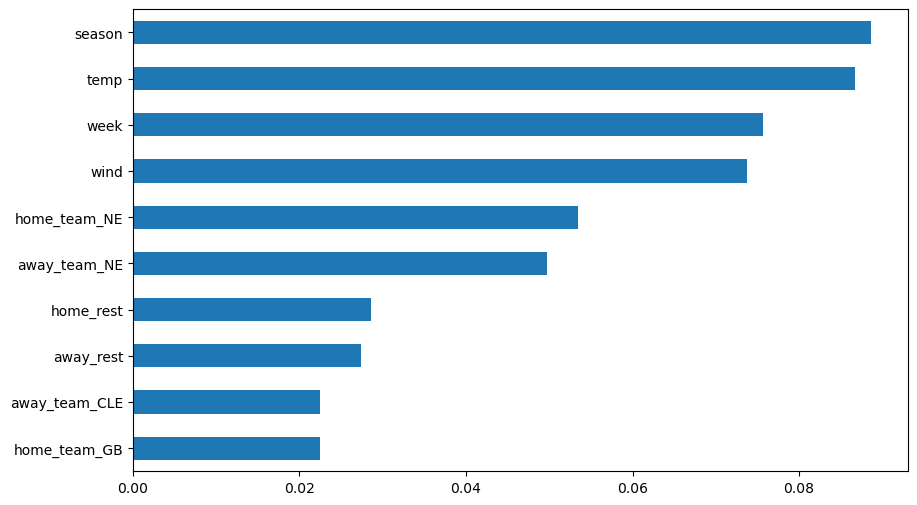

In [51]:
feature_importance.sort_values(ascending=False)[:10].plot(kind='barh', figsize=(10, 6)).invert_yaxis()

In [52]:
df.head(5)

,game_id,season,game_type,week,gameday,weekday,gametime,away_team,away_score,home_team,home_score,location,result,total,overtime,old_game_id,gsis,nfl_detail_id,pfr,pff,espn,ftn,away_rest,home_rest,away_moneyline,home_moneyline,spread_line,away_spread_odds,home_spread_odds,total_line,under_odds,over_odds,div_game,roof,surface,temp,wind,away_qb_id,home_qb_id,away_qb,home_qb,away_coach,home_coach,referee,stadium_id,stadium
0,1999_01_MIN_ATL,1999,REG,1,1999-09-12,Sunday,NaN,MIN,17.0,ATL,14.0,Home,-3.0,31.0,0.0,1999091210,598.0,NaN,199909120atl,NaN,190912001,NaN,7,7,NaN,NaN,-4.0,NaN,NaN,49.0,NaN,NaN,0,dome,astroturf,NaN,NaN,00-0003761,00-0002876,Randall Cunningham,Chris Chandler,Dennis Green,Dan Reeves,Gerry Austin,ATL00,Georgia Dome
1,1999_01_KC_CHI,1999,REG,1,1999-09-12,Sunday,NaN,KC,17.0,CHI,20.0,Home,3.0,37.0,0.0,1999091206,597.0,NaN,199909120chi,NaN,190912003,NaN,7,7,NaN,NaN,-3.0,NaN,NaN,38.0,NaN,NaN,0,outdoors,grass,80.0,12.0,00-0006300,00-0010560,Elvis Grbac,Shane Matthews,Gunther Cunningham,Dick Jauron,Phil Luckett,CHI98,Soldier Field
2,1999_01_PIT_CLE,1999,REG,1,1999-09-12,Sunday,NaN,PIT,43.0,CLE,0.0,Home,-43.0,43.0,0.0,1999091213,604.0,NaN,199909120cle,NaN,190912005,NaN,7,7,NaN,NaN,-6.0,NaN,NaN,37.0,NaN,NaN,1,outdoors,grass,78.0,12.0,00-0015700,00-0004230,Kordell Stewart,Ty Detmer,Bill Cowher,Chris Palmer,Bob McElwee,CLE00,Cleveland Browns Stadium
3,1999_01_OAK_GB,1999,REG,1,1999-09-12,Sunday,NaN,OAK,24.0,GB,28.0,Home,4.0,52.0,0.0,1999091208,602.0,NaN,199909120gnb,NaN,190912009,NaN,7,7,NaN,NaN,9.0,NaN,NaN,43.0,NaN,NaN,0,outdoors,grass,67.0,10.0,00-0005741,00-0005106,Rich Gannon,Brett Favre,Jon Gruden,Ray Rhodes,Tony Corrente,GNB00,Lambeau Field
4,1999_01_BUF_IND,1999,REG,1,1999-09-12,Sunday,NaN,BUF,14.0,IND,31.0,Home,17.0,45.0,0.0,1999091202,591.0,NaN,199909120clt,NaN,190912011,NaN,7,7,NaN,NaN,-3.0,NaN,NaN,45.5,NaN,NaN,1,dome,astroturf,NaN,NaN,00-0005363,00-0010346,Doug Flutie,Peyton Manning,Wade Phillips,Jim Mora,Ron Blum,IND99,RCA Dome


In [53]:
df["away_rating"] = 1500
df["home_rating"] = 1500

In [54]:
df.head()

,game_id,season,game_type,week,gameday,weekday,gametime,away_team,away_score,home_team,home_score,location,result,total,overtime,old_game_id,gsis,nfl_detail_id,pfr,pff,espn,ftn,away_rest,home_rest,away_moneyline,home_moneyline,spread_line,away_spread_odds,home_spread_odds,total_line,under_odds,over_odds,div_game,roof,surface,temp,wind,away_qb_id,home_qb_id,away_qb,home_qb,away_coach,home_coach,referee,stadium_id,stadium,away_rating,home_rating
0,1999_01_MIN_ATL,1999,REG,1,1999-09-12,Sunday,NaN,MIN,17.0,ATL,14.0,Home,-3.0,31.0,0.0,1999091210,598.0,NaN,199909120atl,NaN,190912001,NaN,7,7,NaN,NaN,-4.0,NaN,NaN,49.0,NaN,NaN,0,dome,astroturf,NaN,NaN,00-0003761,00-0002876,Randall Cunningham,Chris Chandler,Dennis Green,Dan Reeves,Gerry Austin,ATL00,Georgia Dome,1500,1500
1,1999_01_KC_CHI,1999,REG,1,1999-09-12,Sunday,NaN,KC,17.0,CHI,20.0,Home,3.0,37.0,0.0,1999091206,597.0,NaN,199909120chi,NaN,190912003,NaN,7,7,NaN,NaN,-3.0,NaN,NaN,38.0,NaN,NaN,0,outdoors,grass,80.0,12.0,00-0006300,00-0010560,Elvis Grbac,Shane Matthews,Gunther Cunningham,Dick Jauron,Phil Luckett,CHI98,Soldier Field,1500,1500
2,1999_01_PIT_CLE,1999,REG,1,1999-09-12,Sunday,NaN,PIT,43.0,CLE,0.0,Home,-43.0,43.0,0.0,1999091213,604.0,NaN,199909120cle,NaN,190912005,NaN,7,7,NaN,NaN,-6.0,NaN,NaN,37.0,NaN,NaN,1,outdoors,grass,78.0,12.0,00-0015700,00-0004230,Kordell Stewart,Ty Detmer,Bill Cowher,Chris Palmer,Bob McElwee,CLE00,Cleveland Browns Stadium,1500,1500
3,1999_01_OAK_GB,1999,REG,1,1999-09-12,Sunday,NaN,OAK,24.0,GB,28.0,Home,4.0,52.0,0.0,1999091208,602.0,NaN,199909120gnb,NaN,190912009,NaN,7,7,NaN,NaN,9.0,NaN,NaN,43.0,NaN,NaN,0,outdoors,grass,67.0,10.0,00-0005741,00-0005106,Rich Gannon,Brett Favre,Jon Gruden,Ray Rhodes,Tony Corrente,GNB00,Lambeau Field,1500,1500
4,1999_01_BUF_IND,1999,REG,1,1999-09-12,Sunday,NaN,BUF,14.0,IND,31.0,Home,17.0,45.0,0.0,1999091202,591.0,NaN,199909120clt,NaN,190912011,NaN,7,7,NaN,NaN,-3.0,NaN,NaN,45.5,NaN,NaN,1,dome,astroturf,NaN,NaN,00-0005363,00-0010346,Doug Flutie,Peyton Manning,Wade Phillips,Jim Mora,Ron Blum,IND99,RCA Dome,1500,1500


In [95]:
def create_points(df, week_change=-1, return_dict=False):
    # week_change: sets the week from which the season stats are used and no longer the overall stats. if week_change = -1, only the overall stats are used
    df["away_avg_points"] = 0
    df["home_avg_points"] = 0
    df["away_avg_points_allowed"] = 0
    df["home_avg_points_allowed"] = 0
    
    # FUTURE: create a function to calculate the average of the last x seasons
    
    current_season = df.iloc[0]['season']
    # Create two dictionaries for each team, one for overall points and one for season points
    team_points_overall = {team: {"avg_points": 0, 
                                  "avg_points_allowed": 0, 
                                  "points": 0, 
                                  "points_allowed": 0, 
                                  "games_played": 0} for team in set(df['away_team']).union(set(df['home_team']))}
    for season in df["season"].unique():
        season_dict[season] = {team: {"avg_points": 0, 
                                      "avg_points_allowed": 0, 
                                      "points": 0, 
                                      "points_allowed": 0, 
                                      "games_played": 0} for team in set(df['away_team']).union(set(df['home_team']))}
     
    for index, row in df.iterrows():
        season = row['season']
        week = row["week"]
        
        # If we've reached a new season, reset season stats
        if season != current_season:
            current_season = season
    
        away_team = row['away_team']
        home_team = row['home_team']
        away_points = row["away_score"]
        home_points = row["home_score"]
        
        # Assign the current points to the DataFrame before they are updated
        # check for week_change, if reached, use season stats instead of overall stats
        if week == week_change:
            df.at[index, 'away_avg_points'] = season_dict[current_season][away_team]["avg_points"]
            df.at[index, 'away_avg_points_allowed'] = season_dict[current_season][away_team]["avg_points_allowed"]
            df.at[index, 'home_avg_points'] = season_dict[current_season][home_team]["avg_points"]
            df.at[index, 'home_avg_points_allowed'] = season_dict[current_season][home_team]["avg_points_allowed"]
        else:
            df.at[index, 'away_avg_points'] = team_points_overall[away_team]["avg_points"]
            df.at[index, 'away_avg_points_allowed'] = team_points_overall[away_team]["avg_points_allowed"]
            df.at[index, 'home_avg_points'] = team_points_overall[home_team]["avg_points"]
            df.at[index, 'home_avg_points_allowed'] = team_points_overall[home_team]["avg_points_allowed"]
        
            
        
        # Set new points for overall stats
        # AWAY
        team_points_overall[away_team]["games_played"] += 1
        team_points_overall[away_team]["points"] += away_points
        team_points_overall[away_team]["points_allowed"] += home_points
        team_points_overall[away_team]["avg_points"] = team_points_overall[away_team]["points"] / team_points_overall[away_team]["games_played"]
        team_points_overall[away_team]["avg_points_allowed"] = team_points_overall[away_team]["points_allowed"] / team_points_overall[away_team]["games_played"]        
        # HOME
        team_points_overall[home_team]["games_played"] += 1
        team_points_overall[home_team]["points"] += home_points
        team_points_overall[home_team]["points_allowed"] += away_points
        team_points_overall[home_team]["avg_points"] = team_points_overall[home_team]["points"] / team_points_overall[home_team]["games_played"]
        team_points_overall[home_team]["avg_points_allowed"] = team_points_overall[home_team]["points_allowed"] / team_points_overall[home_team]["games_played"]  
        
        # Set new points for season stats
        # AWAY
        season_dict[current_season][away_team]["games_played"] += 1
        season_dict[current_season][away_team]["points"] += away_points
        season_dict[current_season][away_team]["points_allowed"] += home_points
        season_dict[current_season][away_team]["avg_points"] = season_dict[current_season][away_team]["points"] / season_dict[current_season][away_team]["games_played"]
        season_dict[current_season][away_team]["avg_points_allowed"] = season_dict[current_season][away_team]["points_allowed"] / season_dict[current_season][away_team]["games_played"]        
        # HOME
        season_dict[current_season][home_team]["games_played"] += 1
        season_dict[current_season][home_team]["points"] += home_points
        season_dict[current_season][home_team]["points_allowed"] += away_points
        season_dict[current_season][home_team]["avg_points"] = season_dict[current_season][home_team]["points"] / season_dict[current_season][home_team]["games_played"]
        season_dict[current_season][home_team]["avg_points_allowed"] = season_dict[current_season][home_team]["points_allowed"] / season_dict[current_season][home_team]["games_played"]
    
    if return_dict == True:
        return df, season_dict
    return df

In [96]:
df_point_test = df_clean.copy()
df_point_test = create_points(df_point_test)

In [94]:
df_point_test.iloc[40:60]

,season,game_type,week,gameday,weekday,gametime,away_team,away_score,home_team,home_score,location,result,total,away_rest,home_rest,div_game,roof,surface,temp,wind,away_qb,home_qb,away_coach,home_coach,referee,stadium,away_rating,home_rating,gametime_h,datetime,month,win,away_avg_points,home_avg_points,away_avg_points_allowed,home_avg_points_allowed
40,2000,REG,3,2000-09-17,Sunday,16:15,MIN,21.0,NE,13.0,Home,-8.0,34.0,7,6,0,outdoors,grass,70.0,15.00,Daunte Culpepper,Drew Bledsoe,Dennis Green,Bill Belichick,Phil Luckett,Foxboro Stadium,1500,1500,16,2000-09-17 16:15:00,9,0,21.500000,17.500000,17.000000,20.500000
41,2000,REG,3,2000-09-17,Sunday,16:15,NO,10.0,SEA,20.0,Home,10.0,30.0,7,7,0,outdoors,synthetic,68.0,3.00,Jeff Blake,Jon Kitna,Jim Haslett,Mike Holmgren,Walt Coleman,Husky Stadium,1500,1500,16,2000-09-17 16:15:00,9,1,19.000000,17.000000,20.500000,30.000000
42,2000,REG,3,2000-09-17,Sunday,20:20,BAL,6.0,MIA,19.0,Home,13.0,25.0,7,7,0,outdoors,grass,80.0,10.00,Tony Banks,Jay Fiedler,Brian Billick,Dave Wannstedt,Jeff Triplette,Pro Player Stadium,1500,1500,20,2000-09-17 20:20:00,9,1,27.500000,15.000000,18.000000,6.500000
43,2000,REG,3,2000-09-18,Monday,09:00,DAL,27.0,WAS,21.0,Home,-6.0,48.0,8,8,1,outdoors,grass,66.0,8.00,Randall Cunningham,Brad Johnson,Dave Campo,Norv Turner,Bill Carollo,FedExField,1500,1500,9,2000-09-18 09:00:00,9,0,22.500000,15.000000,36.500000,16.000000
44,2000,REG,4,2000-09-24,Sunday,13:00,LA,41.0,ATL,20.0,Home,-21.0,61.0,7,7,1,dome,synthetic,61.2,8.40,Kurt Warner,Chris Chandler,Mike Martz,Dan Reeves,Bill Carollo,Georgia Dome,1500,1500,13,2000-09-24 13:00:00,9,0,39.666667,21.666667,31.333333,26.666667
45,2000,REG,4,2000-09-24,Sunday,13:00,CIN,0.0,BAL,37.0,Home,37.0,37.0,7,7,1,outdoors,grass,70.0,5.00,Akili Smith,Tony Banks,Bruce Coslet,Brian Billick,Bob McElwee,PSINet Stadium,1500,1500,13,2000-09-24 13:00:00,9,1,3.500000,20.333333,18.500000,18.333333
46,2000,REG,4,2000-09-24,Sunday,13:00,DET,21.0,CHI,14.0,Home,-7.0,35.0,7,7,1,outdoors,grass,58.0,12.00,Charlie Batch,Cade McNown,Bobby Ross,Dick Jauron,Ron Blum,Soldier Field,1500,1500,13,2000-09-24 13:00:00,9,0,13.000000,11.333333,17.000000,28.333333
47,2000,REG,4,2000-09-24,Sunday,13:00,SF,41.0,DAL,24.0,Home,-17.0,65.0,7,6,0,outdoors,synthetic,64.0,20.00,Jeff Garcia,Troy Aikman,Steve Mariucci,Dave Campo,Jeff Triplette,Texas Stadium,1500,1500,13,2000-09-24 13:00:00,9,0,24.666667,24.000000,38.333333,31.333333
48,2000,REG,4,2000-09-24,Sunday,13:00,NE,3.0,MIA,10.0,Home,7.0,13.0,7,7,1,outdoors,grass,88.0,12.00,Drew Bledsoe,Jay Fiedler,Bill Belichick,Dave Wannstedt,Ed Hochuli,Pro Player Stadium,1500,1500,13,2000-09-24 13:00:00,9,1,16.000000,16.333333,20.666667,6.333333
49,2000,REG,4,2000-09-24,Sunday,13:00,PHI,21.0,NO,7.0,Home,-14.0,28.0,7,7,0,dome,synthetic,61.2,7.60,Donovan McNabb,Jeff Blake,Andy Reid,Jim Haslett,Gerry Austin,Louisiana Superdome,1500,1500,13,2000-09-24 13:00:00,9,0,20.666667,16.000000,17.666667,20.333333


In [104]:
def create_elo_rating(df, alpha = 0):
    # Initialize the DataFrame with Elo score columns
    df['away_elo'] = 0
    df['home_elo'] = 0
    df["away_qb_elo"] = 0
    df["home_qb_elo"] = 0
    df["away_coach_elo"] = 0
    df["home_coach_elo"] = 0
    
    # Function to calculate the expected score
    def expected_score(Ra, Rb):
        return 1 / (1 + 10 ** ((Rb - Ra) / 400))
    
    # Function to update Elo ratings after a game
    def update_elo(winner_elo, loser_elo):
        E_winner = expected_score(winner_elo, loser_elo)
        E_loser = 1 - E_winner
        
        new_winner_elo = winner_elo + K * (1 - E_winner)
        new_loser_elo = loser_elo + K * (0 - E_loser)
        
        return new_winner_elo, new_loser_elo
    
    # Elo Rating System constants
    K = 32
    BASE_ELO = 1500
    # Initialize Elo ratings for teams
    team_elos = {team: BASE_ELO for team in set(df['away_team']).union(set(df['home_team']))}
    qb_elos = {qb: BASE_ELO for qb in set(df['away_qb']).union(set(df['home_qb']))}
    coach_elos = {coach: BASE_ELO for coach in set(df['away_coach']).union(set(df['home_coach']))}
    current_season = df.iloc[0]['season']

    # Sort the DataFrame by season and game_week to ensure chronological order
    #df.sort_values(by=['season', 'game_week'], inplace=True)

    # not doing a hard rest, we will do a soft reset 
    # New Rating= α × Old Rating + (1 − α) × Reference Rating
    # Smaller α gives more weight to Reference Rating(BASE_ELO), signifies the reset is more impactful
    # alpha = 0 means HARD reset
    # alpha = 1 NO reset
    if alpha > 1:
        alpha = 1
    elif alpha < 0:
        alpha = 0
        
    def reset_elos():
        for team in team_elos.keys():
            team_elos[team] = alpha * team_elos[team] + (1 - alpha) * BASE_ELO
        for qb in qb_elos.keys():
            qb_elos[qb] = alpha * qb_elos[qb] + (1 - alpha) * BASE_ELO
        for coach in coach_elos.keys():
            coach_elos[coach] = alpha * coach_elos[coach] + (1 - alpha) * BASE_ELO

    # Iterate over games, update Elo ratings and add them to the DataFrame
    for index, row in df.iterrows():
        season = row['season']

        # If we've reached a new season, reset the Elo ratings
        if season != current_season:
            reset_elos()
            current_season = season

        away_team = row['away_team']
        home_team = row['home_team']
        away_qb = row['away_qb']
        home_qb = row['home_qb']
        away_coach = row['away_coach']
        home_coach = row['home_coach']

        # Assign the current Elo ratings to the DataFrame before they are updated
        # Teams
        df.at[index, 'away_elo'] = team_elos[away_team]
        df.at[index, 'home_elo'] = team_elos[home_team]
        # Quaterbacks
        df.at[index, 'away_qb_elo'] = qb_elos[away_qb]
        df.at[index, 'home_qb_elo'] = qb_elos[home_qb]
        # Coaches
        df.at[index, 'away_coach_elo'] = coach_elos[away_coach]
        df.at[index, 'home_coach_elo'] = coach_elos[home_coach]
        
        # cant use score, because we obviously have no future scores
        #away_score = row['away_score']
        #home_score = row['home_score']

        #if away_score > home_score:
        #    winner_team, loser_team = away_team, home_team
        #    winner_qb, loser_qb = away_qb, home_qb
        #    winner_coach, loser_coach = away_coach, home_coach
        #else:
        #    winner_team, loser_team = home_team, away_team
        #    winner_qb, loser_qb = home_qb, away_qb
        #    winner_coach, loser_coach = home_coach, away_coach
        
        win = row["win"]
        if win == 0:
            winner_team, loser_team = away_team, home_team
            winner_qb, loser_qb = away_qb, home_qb
            winner_coach, loser_coach = away_coach, home_coach
        else:
            winner_team, loser_team = home_team, away_team
            winner_qb, loser_qb = home_qb, away_qb
            winner_coach, loser_coach = home_coach, away_coach

        # Update Elo ratings based on game result
        # Teams
        new_winner_team_elo, new_loser_team_elo = update_elo(team_elos[winner_team], team_elos[loser_team])
        # Quaterbacks
        new_winner_qb_elo, new_loser_qb_elo = update_elo(qb_elos[winner_qb], qb_elos[loser_qb])
        # Coaches
        new_winner_coach_elo, new_loser_coach_elo = update_elo(coach_elos[winner_coach], coach_elos[loser_coach])
        
        # Set new Elo ratings
        #Teams
        team_elos[winner_team] = new_winner_team_elo
        team_elos[loser_team] = new_loser_team_elo
        # Quaterbacks
        qb_elos[winner_qb] = new_winner_qb_elo
        qb_elos[loser_qb] = new_loser_qb_elo
        # Coaches
        coach_elos[winner_coach] = new_winner_coach_elo
        coach_elos[loser_coach] = new_loser_coach_elo
    
    return df

In [105]:
def feature_eng(df, season_start=2000, alpha=0, week_change=-1):
    df = clean_df(df, season_start)
    # we dont need "return_dict", because its more like a debug feature and if we want to use it, we call create_score on its own
    df = create_points(df, week_change)
    df = create_elo_rating(df, alpha)
    
    # drop columns, we needed for web crawling or creating additional features
    # overtime isnt irrelevant, but we dont have this feature for future games, so we drop it. (we could predict it too, but it's not worth)
    df = df.drop(columns=['game_id', 'old_game_id', 'gsis', 'nfl_detail_id', 'pfr', 'pff', 'espn', 'ftn', 'overtime'])
    # drop scores, totals and result
    df = df.drop(columns=["away_score", "home_score", "total", "result"])
    
    return df

In [106]:
df_f_test = feature_eng(df)

In [108]:
df_f_test.tail()

,season,game_type,week,gameday,weekday,gametime,away_team,home_team,location,away_rest,home_rest,div_game,roof,surface,temp,wind,away_qb,home_qb,away_coach,home_coach,referee,stadium,away_rating,home_rating,gametime_h,datetime,month,win,away_avg_points,home_avg_points,away_avg_points_allowed,home_avg_points_allowed,away_elo,home_elo,away_qb_elo,home_qb_elo,away_coach_elo,home_coach_elo
6439,2023,WC,19,2024-01-15,Monday,20:00,PHI,TB,Home,8,8,0,outdoors,grass,65.0,2.0,Jalen Hurts,Baker Mayfield,Nick Sirianni,Todd Bowles,Adrian Hill,Raymond James Stadium,1500,1500,20,2024-01-15 20:00:00,1,1,24.230216,21.391521,20.884892,21.680798,1531.895406,1509.864414,1538.920297,1514.011283,1532.008955,1518.318061
6440,2023,DIV,20,2024-01-20,Saturday,16:30,HOU,BAL,Home,7,14,0,outdoors,grass,27.0,16.0,C.J. Stroud,Lamar Jackson,DeMeco Ryans,John Harbaugh,John Hussey,M&T Bank Stadium,1500,1500,16,2024-01-20 16:30:00,1,1,20.702186,22.773494,23.191257,18.368675,1556.482666,1613.698874,1562.200363,1636.123428,1556.591334,1613.751521
6441,2023,DIV,20,2024-01-20,Saturday,20:15,GB,SF,Home,6,13,0,outdoors,grass,59.0,8.0,Jordan Love,Brock Purdy,Matt LaFleur,Kyle Shanahan,Alex Kemp,Levi's Stadium,1500,1500,20,2024-01-20 20:15:00,1,1,25.390887,21.997543,21.695444,22.007371,1539.228752,1576.816865,1545.503686,1611.636434,1543.586235,1576.835076
6442,2023,DIV,20,2024-01-21,Sunday,15:00,TB,DET,Home,6,7,0,dome,synthetic,61.2,9.8,Baker Mayfield,Jared Goff,Todd Bowles,Dan Campbell,Bill Vinovich,Ford Field,1500,1500,15,2024-01-21 15:00:00,1,1,21.417910,21.179028,21.649254,25.071611,1526.877621,1588.065297,1531.156425,1589.512766,1534.948224,1588.182508
6443,2023,DIV,20,2024-01-21,Sunday,18:30,KC,BUF,Home,8,6,0,outdoors,synthetic,31.0,10.0,Patrick Mahomes,Josh Allen,Andy Reid,Sean McDermott,Shawn Hochuli,New Era Field,1500,1500,18,2024-01-21 18:30:00,1,0,24.190244,21.454545,21.948780,21.772727,1560.605307,1588.277605,1556.304280,1593.912245,1562.612337,1588.471948


In [56]:
# feature engineering
# https://towardsdatascience.com/developing-an-elo-based-data-driven-ranking-system-for-2v2-multiplayer-games-7689f7d42a53
# dictionary with coaches [Total Games - W/L Ratio - Games with Team]
# dictionary with qbs [Total Games - W/L Ratio - Games with Team]

In [57]:
df_clean.head()

,season,game_type,week,gameday,weekday,gametime,away_team,home_team,location,away_rest,home_rest,div_game,roof,surface,temp,wind,away_qb,home_qb,away_coach,home_coach,referee,stadium,gametime_h,datetime,month,win
0,2000,REG,1,2000-09-03,Sunday,13:00,SF,ATL,Home,7,7,1,dome,synthetic,61.2,8.4,Jeff Garcia,Chris Chandler,Steve Mariucci,Dan Reeves,Walt Coleman,Georgia Dome,13,2000-09-03 13:00:00,9,1
1,2000,REG,1,2000-09-03,Sunday,13:00,JAX,CLE,Home,7,7,1,outdoors,grass,78.0,6.0,Mark Brunell,Tim Couch,Tom Coughlin,Chris Palmer,Bernie Kukar,Cleveland Browns Stadium,13,2000-09-03 13:00:00,9,0
2,2000,REG,1,2000-09-03,Sunday,13:00,IND,KC,Home,7,7,0,outdoors,grass,90.0,5.0,Peyton Manning,Elvis Grbac,Jim Mora,Gunther Cunningham,Larry Nemmers,Arrowhead Stadium,13,2000-09-03 13:00:00,9,0
3,2000,REG,1,2000-09-03,Sunday,13:00,CHI,MIN,Home,7,7,1,dome,synthetic,61.2,8.9,Cade McNown,Daunte Culpepper,Dick Jauron,Dennis Green,Ed Hochuli,Hubert H. Humphrey Metrodome,13,2000-09-03 13:00:00,9,1
4,2000,REG,1,2000-09-03,Sunday,13:00,TB,NE,Home,7,7,0,outdoors,grass,71.0,5.0,Shaun King,Drew Bledsoe,Tony Dungy,Bill Belichick,Jeff Triplette,Foxboro Stadium,13,2000-09-03 13:00:00,9,0


In [58]:
df_elo_test = clean_df(df)

In [59]:
df_elo_test_elo = create_elo_rating(df_elo_test)

In [60]:
df_elo_test_elo = df_elo_test_elo[['season', 'game_type', 'week', 'away_team', 'away_elo', 'home_team', 'home_elo', "away_qb_elo", "home_qb_elo", "away_coach_elo",
                                   "home_coach_elo", 'location', 'away_rest', 'home_rest', 'div_game','roof', 'surface', 'temp', 'wind', 'win']]

In [61]:
df_elo_test_elo.head()

,season,game_type,week,away_team,away_elo,home_team,home_elo,away_qb_elo,home_qb_elo,away_coach_elo,home_coach_elo,location,away_rest,home_rest,div_game,roof,surface,temp,wind,win
0,2000,REG,1,SF,1500.0,ATL,1500.0,1500.0,1500.0,1500.0,1500.0,Home,7,7,1,dome,synthetic,61.2,8.4,1
1,2000,REG,1,JAX,1500.0,CLE,1500.0,1500.0,1500.0,1500.0,1500.0,Home,7,7,1,outdoors,grass,78.0,6.0,0
2,2000,REG,1,IND,1500.0,KC,1500.0,1500.0,1500.0,1500.0,1500.0,Home,7,7,0,outdoors,grass,90.0,5.0,0
3,2000,REG,1,CHI,1500.0,MIN,1500.0,1500.0,1500.0,1500.0,1500.0,Home,7,7,1,dome,synthetic,61.2,8.9,1
4,2000,REG,1,TB,1500.0,NE,1500.0,1500.0,1500.0,1500.0,1500.0,Home,7,7,0,outdoors,grass,71.0,5.0,0


In [62]:
df_elo_test_elo.iloc[-20:,:]

,season,game_type,week,away_team,away_elo,home_team,home_elo,away_qb_elo,home_qb_elo,away_coach_elo,home_coach_elo,location,away_rest,home_rest,div_game,roof,surface,temp,wind,win
6424,2023,REG,18,ATL,1457.535249,NO,1495.111613,1486.038827,1498.345197,1462.132679,1499.784235,Home,7,7,1,dome,synthetic,61.2,7.6,1
6425,2023,REG,18,JAX,1513.754577,TEN,1425.715151,1503.822900,1468.574290,1518.191411,1425.766518,Home,7,7,1,outdoors,grass,41.0,11.0,1
6426,2023,REG,18,SEA,1498.415655,ARI,1424.764670,1482.579246,1494.199027,1498.420689,1424.767005,Home,7,7,1,closed,grass,61.2,4.7,0
6427,2023,REG,18,CHI,1493.584032,GB,1504.950717,1500.868095,1511.366124,1493.805961,1509.715882,Home,7,7,1,outdoors,grass,34.0,7.0,1
6428,2023,REG,18,KC,1533.574424,LAC,1419.810497,1500.000000,1454.365015,1535.666125,1420.907759,Home,7,7,1,dome,synthetic,61.2,3.5,0
6429,2023,REG,18,DEN,1509.468214,LV,1476.636000,1514.573358,1487.563543,1509.523614,1499.221429,Home,7,7,1,dome,grass,61.2,6.3,1
6430,2023,REG,18,PHI,1553.179542,NYG,1433.968011,1558.994632,1468.531204,1553.241746,1435.280163,Home,7,7,1,outdoors,synthetic,36.0,12.0,1
6431,2023,REG,18,LA,1535.076541,SF,1595.575106,1500.000000,1500.000000,1535.356535,1595.581071,Home,7,7,1,outdoors,grass,52.0,11.0,0
6432,2023,REG,18,DAL,1573.546938,WAS,1392.499647,1575.792954,1399.651667,1573.658235,1392.658516,Home,8,7,1,outdoors,grass,48.0,13.0,0
6433,2023,REG,18,BUF,1557.559219,MIA,1562.714609,1564.026973,1566.738464,1557.716750,1563.866473,Home,7,7,1,outdoors,grass,63.0,6.0,0


In [63]:
# split df_base into train & test set
df_base_train_elo = df_elo_test_elo.loc[df["season"] < 2020]
df_base_test_elo = df_elo_test_elo.loc[df["season"] >= 2020]

# split further into features & target
features_base_train_elo = df_base_train_elo.drop(columns="win")
target_base_train_elo = df_base_train_elo["win"]
features_base_test_elo = df_base_test_elo.drop(columns="win")
target_base_test_elo = df_base_test_elo["win"]

# split columns into categorical and numerical cols for future use (Cat for Onehotencoding - Num for Scaling)
num_cols = features_base_train_elo.select_dtypes(include=[np.number]).columns
cat_cols = features_base_train_elo.select_dtypes(exclude=[np.number]).columns

features_base_train_elo_ohe = pd.DataFrame(ohe.fit_transform(features_base_train_elo[cat_cols]).toarray(), columns=list(ohe.get_feature_names_out()))

features_base_train_elo_scaled = pd.DataFrame(scaler.fit_transform(features_base_train_elo[num_cols]), columns=num_cols)

features_base_train_elo_enc = pd.concat([features_base_train_elo_scaled, features_base_train_elo_ohe], axis=1, join="inner")

features_base_test_elo_ohe = pd.DataFrame(ohe.transform(features_base_test_elo[cat_cols]).toarray(), columns=list(ohe.get_feature_names_out()))
features_base_test_elo_scaled = pd.DataFrame(scaler.transform(features_base_test_elo[num_cols]), columns=num_cols)
features_base_test_elo_enc = pd.concat([features_base_test_elo_scaled, features_base_test_elo_ohe], axis=1, join="inner")

In [64]:
features_base_test_elo_enc.head()

,season,week,away_elo,home_elo,away_qb_elo,home_qb_elo,away_coach_elo,home_coach_elo,away_rest,home_rest,div_game,temp,wind,game_type_CON,game_type_DIV,game_type_REG,game_type_SB,game_type_WC,away_team_ARI,away_team_ATL,away_team_BAL,away_team_BUF,away_team_CAR,away_team_CHI,away_team_CIN,away_team_CLE,away_team_DAL,away_team_DEN,away_team_DET,away_team_GB,away_team_HOU,away_team_IND,away_team_JAX,away_team_KC,away_team_LA,away_team_LAC,away_team_LV,away_team_MIA,away_team_MIN,away_team_NE,away_team_NO,away_team_NYG,away_team_NYJ,away_team_PHI,away_team_PIT,away_team_SEA,away_team_SF,away_team_TB,away_team_TEN,away_team_WAS,home_team_ARI,home_team_ATL,home_team_BAL,home_team_BUF,home_team_CAR,home_team_CHI,home_team_CIN,home_team_CLE,home_team_DAL,home_team_DEN,home_team_DET,home_team_GB,home_team_HOU,home_team_IND,home_team_JAX,home_team_KC,home_team_LA,home_team_LAC,home_team_LV,home_team_MIA,home_team_MIN,home_team_NE,home_team_NO,home_team_NYG,home_team_NYJ,home_team_PHI,home_team_PIT,home_team_SEA,home_team_SF,home_team_TB,home_team_TEN,home_team_WAS,location_Home,location_Neutral,roof_closed,roof_dome,roof_open,roof_outdoors,surface_grass,surface_synthetic
0,1.654858,1.615981,1.367248,1.210259,1.779248,1.344488,1.375491,1.308917,-0.24818,-0.246444,-0.779451,-1.756970,-1.526387,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
1,1.654858,1.615981,-0.274347,1.754115,0.596386,1.660970,-0.212904,1.839915,-0.24818,-0.246444,-0.779451,0.153426,-0.150979,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,1.654858,1.615981,1.197016,1.346852,1.331411,2.019723,1.232822,1.353474,-0.24818,-0.246444,1.282954,-1.689225,-1.526387,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
3,1.654858,1.805998,1.079259,2.094603,0.382890,2.430417,1.076582,2.182526,-0.24818,2.624994,-0.779451,-1.621481,0.974354,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
4,1.654858,1.805998,1.680455,2.670007,2.130576,2.997813,1.698287,2.692064,-0.74749,-0.246444,-0.779451,-1.689225,0.974354,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0


In [65]:
search_space_rf = {'max_depth': np.geomspace(start=20, stop=200, num=10, dtype='int'),
                   'min_samples_leaf': np.geomspace(start=1, stop=500, num=10, dtype='int')}

model_rf = GridSearchCV(estimator=RandomForestClassifier(n_estimators=50),
                                                         param_grid=search_space_rf,
                                                         scoring='precision',
                                                         cv=5,
                                                         n_jobs=-1)
                                                                                 
# Fit on Train Data
model_rf.fit(features_base_train_elo_enc, target_base_train)
# Predict Target Test
target_base_test_elo_pred = model_rf.predict(features_base_test_elo_enc)
# Print Metrics
print("-----RandomForest-----")
print("Best Parameter: {}".format(model_rf.best_params_))
print(classification_report(target_base_test, target_base_test_elo_pred))

-----RandomForest-----
Best Parameter: {'max_depth': 71, 'min_samples_leaf': 3}
              precision    recall  f1-score   support

           0       0.52      0.46      0.49       389
           1       0.60      0.66      0.62       472

    accuracy                           0.57       861
   macro avg       0.56      0.56      0.56       861
weighted avg       0.56      0.57      0.56       861



In [66]:
search_space_rf = {'max_depth': np.geomspace(start=20, stop=200, num=10, dtype='int'),
                   'min_samples_leaf': np.geomspace(start=1, stop=500, num=10, dtype='int')}

model_rf = GridSearchCV(estimator=RandomForestClassifier(n_estimators=50),
                                                         param_grid=search_space_rf,
                                                         scoring='precision',
                                                         cv=5,
                                                         n_jobs=-1)
                                                                                 
# Fit on Train Data
model_rf.fit(features_base_train_elo_enc, target_base_train)
# Predict Target Test
target_base_test_elo_pred = model_rf.predict(features_base_test_elo_enc)
# Print Metrics
print("-----RandomForest-----")
print("Best Parameter: {}".format(model_rf.best_params_))
print(classification_report(target_base_test, target_base_test_elo_pred))

-----RandomForest-----
Best Parameter: {'max_depth': 200, 'min_samples_leaf': 1}
              precision    recall  f1-score   support

           0       0.52      0.51      0.51       389
           1       0.60      0.61      0.60       472

    accuracy                           0.56       861
   macro avg       0.56      0.56      0.56       861
weighted avg       0.56      0.56      0.56       861



In [67]:
search_space_rf = {'max_depth': np.geomspace(start=20, stop=200, num=10, dtype='int'),
                   'min_samples_leaf': np.geomspace(start=1, stop=500, num=10, dtype='int')}

model_rf = GridSearchCV(estimator=RandomForestClassifier(n_estimators=50),
                                                         param_grid=search_space_rf,
                                                         scoring='accuracy',
                                                         cv=5,
                                                         n_jobs=-1)
                                                                                 
# Fit on Train Data
model_rf.fit(features_base_train_elo_enc, target_base_train)
# Predict Target Test
target_base_test_elo_pred = model_rf.predict(features_base_test_elo_enc)
# Print Metrics
print("-----RandomForest-----")
print("Best Parameter: {}".format(model_rf.best_params_))
print(classification_report(target_base_test, target_base_test_elo_pred))

-----RandomForest-----
Best Parameter: {'max_depth': 20, 'min_samples_leaf': 31}
              precision    recall  f1-score   support

           0       0.55      0.37      0.44       389
           1       0.59      0.75      0.66       472

    accuracy                           0.58       861
   macro avg       0.57      0.56      0.55       861
weighted avg       0.57      0.58      0.56       861



In [68]:
df_clean_elo_soft = clean_df(df)
df_clean_elo_soft = create_elo_rating(df_clean_elo_soft, 0.75)
df_clean_elo_soft = df_clean_elo_soft[['season', 'game_type', 'week', 'away_team', 'away_elo', 'home_team', 'home_elo', "away_qb_elo", "home_qb_elo", "away_coach_elo",
                                       "home_coach_elo", 'location', 'away_rest', 'home_rest', 'div_game','roof', 'surface', 'temp', 'wind', 'win']]

In [69]:
# split df_base into train & test set
df_base_train_elo_soft = df_clean_elo_soft.loc[df["season"] < 2020]
df_base_test_elo_soft = df_clean_elo_soft.loc[df["season"] >= 2020]

# split further into features & target
features_base_train_elo_soft = df_base_train_elo_soft.drop(columns="win")
target_base_train_elo_soft = df_base_train_elo_soft["win"]
features_base_test_elo_soft = df_base_test_elo_soft.drop(columns="win")
target_base_test_elo_soft = df_base_test_elo_soft["win"]

# split columns into categorical and numerical cols for future use (Cat for Onehotencoding - Num for Scaling)
num_cols = features_base_train_elo_soft.select_dtypes(include=[np.number]).columns
cat_cols = features_base_train_elo_soft.select_dtypes(exclude=[np.number]).columns

features_base_train_elo_soft_ohe = pd.DataFrame(ohe.fit_transform(features_base_train_elo_soft[cat_cols]).toarray(), columns=list(ohe.get_feature_names_out()))

features_base_train_elo_soft_scaled = pd.DataFrame(scaler.fit_transform(features_base_train_elo_soft[num_cols]), columns=num_cols)

features_base_train_elo_soft_enc = pd.concat([features_base_train_elo_soft_scaled, features_base_train_elo_soft_ohe], axis=1, join="inner")

features_base_test_elo_soft_ohe = pd.DataFrame(ohe.transform(features_base_test_elo_soft[cat_cols]).toarray(), columns=list(ohe.get_feature_names_out()))
features_base_test_elo_soft_scaled = pd.DataFrame(scaler.transform(features_base_test_elo_soft[num_cols]), columns=num_cols)
features_base_test_elo_soft_enc = pd.concat([features_base_test_elo_soft_scaled, features_base_test_elo_soft_ohe], axis=1, join="inner")

In [149]:
search_space_rf = {'max_depth': np.geomspace(start=20, stop=200, num=10, dtype='int'),
                   'min_samples_leaf': np.geomspace(start=1, stop=500, num=10, dtype='int')}

model_rf = GridSearchCV(estimator=RandomForestClassifier(n_estimators=50),
                                                         param_grid=search_space_rf,
                                                         scoring='accuracy',
                                                         cv=5,
                                                         n_jobs=-1)
                                                                                 
# Fit on Train Data
model_rf.fit(features_base_train_elo_soft_enc, target_base_train)
# Predict Target Test
target_base_test_elo_soft_pred = model_rf.predict(features_base_test_elo_soft_enc)
# Print Metrics
print("-----RandomForest-----")
print("Best Parameter: {}".format(model_rf.best_params_))
print(classification_report(target_base_test, target_base_test_elo_soft_pred))

-----RandomForest-----
Best Parameter: {'max_depth': 55, 'min_samples_leaf': 31}
              precision    recall  f1-score   support

           0       0.60      0.43      0.50       389
           1       0.62      0.76      0.68       472

    accuracy                           0.61       861
   macro avg       0.61      0.60      0.59       861
weighted avg       0.61      0.61      0.60       861



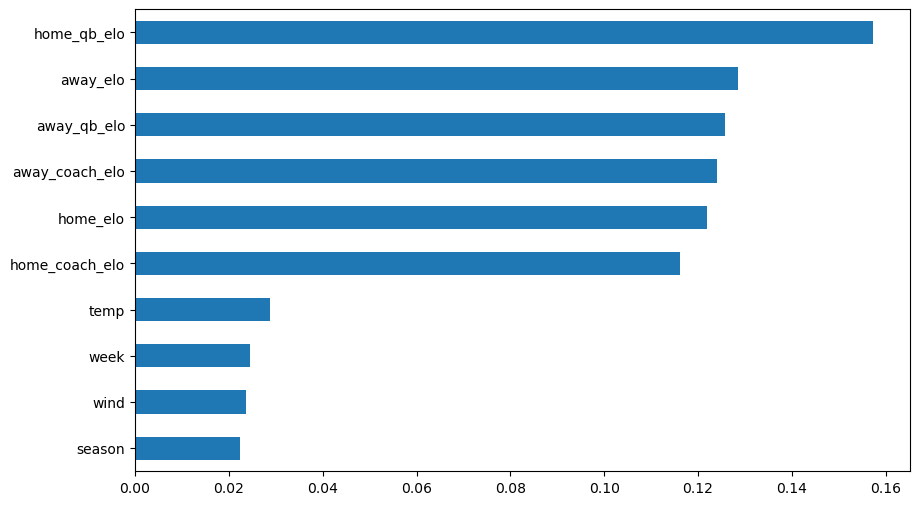

In [153]:
fi = model_rf.best_estimator_.feature_importances_

feature_importance = pd.Series(fi, index=features_base_train_elo_soft_enc.columns)
feature_importance.sort_values(ascending=False)[:10].plot(kind='barh', figsize=(10, 6)).invert_yaxis()

In [146]:
param_grid = {"C": [0.1, 1, 10, 1000],
              "penalty": ["l1", "l2"]}


grid_log_one = GridSearchCV(LogisticRegression(max_iter=1000,
                                               solver="saga"),
                                               param_grid,
                                               cv=5,
                                               scoring="precision",
                                               n_jobs=-1)

# Fit on Train Data
grid_log_one.fit(features_base_train_elo_soft_enc, target_base_train)
# Predict Target Test
target_base_test_elo_soft_pred = grid_log_one.predict(features_base_test_elo_soft_enc)
# Print Metrics
print("-----LogReg-----")
print("Best Parameter: {}".format(grid_log_one.best_params_))
print(classification_report(target_base_test, target_base_test_elo_soft_pred))                                             

-----LogReg-----
Best Parameter: {'C': 0.1, 'penalty': 'l1'}
              precision    recall  f1-score   support

           0       0.59      0.44      0.50       389
           1       0.62      0.75      0.68       472

    accuracy                           0.61       861
   macro avg       0.61      0.59      0.59       861
weighted avg       0.61      0.61      0.60       861



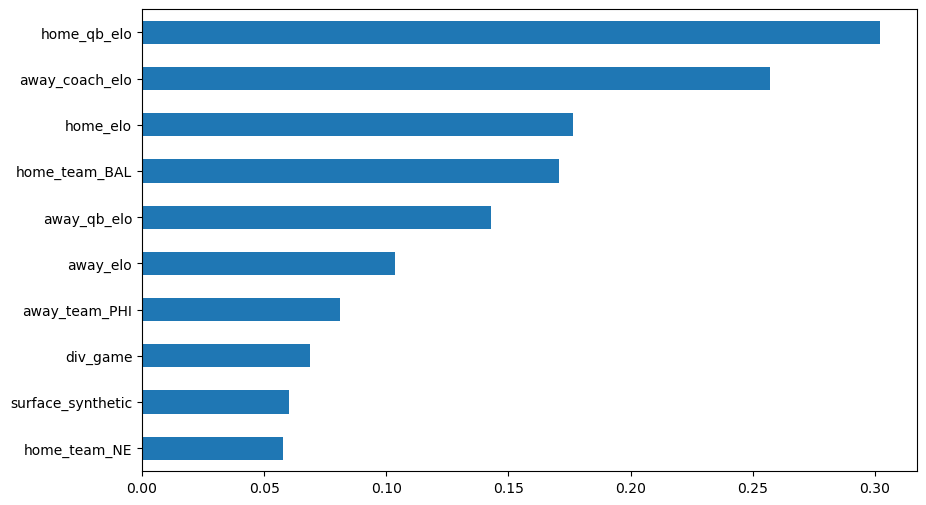

In [147]:
coefficients = grid_log_one.best_estimator_.coef_[0]
feature_importance = pd.Series(np.abs(coefficients), index=features_base_train_elo_soft_enc.columns)
#feature_importance = pd.DataFrame({'Feature': features_base_train_elo_soft_enc.columns, 'Importance': np.abs(coefficients)})
feature_importance = feature_importance.sort_values(ascending=False)
feature_importance[:10].plot(kind='barh', figsize=(10, 6)).invert_yaxis()

In [148]:
xgb = XGBClassifier(objective="binary:logistic", eval_metric="pre")

# Fit on Train Data
xgb.fit(features_base_train_elo_soft_enc, target_base_train)
# Predict Target Test
target_base_test_elo_soft_pred = xgb.predict(features_base_test_elo_soft_enc)
# Print Metrics
print("-----LogReg-----")
#print("Best Parameter: {}".format(xgb.best_params_))
print(classification_report(target_base_test, target_base_test_elo_soft_pred))    

-----LogReg-----
              precision    recall  f1-score   support

           0       0.54      0.53      0.54       389
           1       0.62      0.63      0.62       472

    accuracy                           0.58       861
   macro avg       0.58      0.58      0.58       861
weighted avg       0.58      0.58      0.58       861



In [103]:
# Win probability:
# EA = 1/(1+10^((RH-RA)/400))
# EH = 1/(1+10^((RA-RH)/400))
# EA = Win probability away_team
# EH = Win probability home_team
# RA = Rating away_team
# RH = Rating home_team

In [104]:
# New Rating:
# New RA = Old RA + K * (SA-EA)
# New RH = Old RH + K * (SH-EH)
# SA = Actual Score Team A(Win = 1)
# SB = Actual Score Team B(Loose = 0)
# K determines approximatley how much a player rating can change after a single match
# in chess K = 32, but u can also use a formula for K. to keep it simple we copy 32 from chess
# e.g. if EA = 0,75 (75% probability to win)
# (1-0,5) = 0,25
# (0-0,5)
# New RA = 1500 + 32 * 0,5 = 1516
# New RH = 1500 + 32 * (-0,5) = 1484

In [105]:
## ---------- WEBCRAWLING ----------
#from bs4 import BeautifulSoup
#import requests

In [106]:
#website_url = "https://www.pro-football-reference.com/boxscores/202401130kan.htm"
#response = requests.get(website_url)
#print(response)
#soup = BeautifulSoup(response.text)

In [107]:
#table = soup.find(id="div_scoring")
#for stat in table.find_all("td"):
#    print(stat)

In [108]:
# binary prediction
# when win probability is about 50%+-5% predict tie